In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [4]:
!kaggle datasets download mexwell/fake-reviews-dataset

Dataset URL: https://www.kaggle.com/datasets/mexwell/fake-reviews-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
fake-reviews-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
import zipfile
with zipfile.ZipFile("fake-reviews-dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

In [6]:
df = pd.read_csv("fake reviews dataset.csv")

In [8]:
df = df.rename(columns={
    "text_": "review_text"})

In [9]:
X = df["review_text"]
y = df["label"]

In [10]:
vectorizer = TfidfVectorizer(max_features=3000)
X_vec = vectorizer.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2)

In [12]:
models = {
    "NB": MultinomialNB(),
    "LR": LogisticRegression(max_iter=200),
    "RF": RandomForestClassifier()
}

In [13]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print("Model:", name)
    print(classification_report(y_test, preds))
    print("-"*40)

Model: NB
              precision    recall  f1-score   support

          CG       0.86      0.89      0.87      4020
          OR       0.89      0.85      0.87      4067

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087

----------------------------------------
Model: LR
              precision    recall  f1-score   support

          CG       0.90      0.90      0.90      4020
          OR       0.90      0.91      0.90      4067

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087

----------------------------------------
Model: RF
              precision    recall  f1-score   support

          CG       0.87      0.88      0.88      4020
          OR       0.88      0.87      0.88      4067

    accuracy                           0.88      8087
   macro avg    

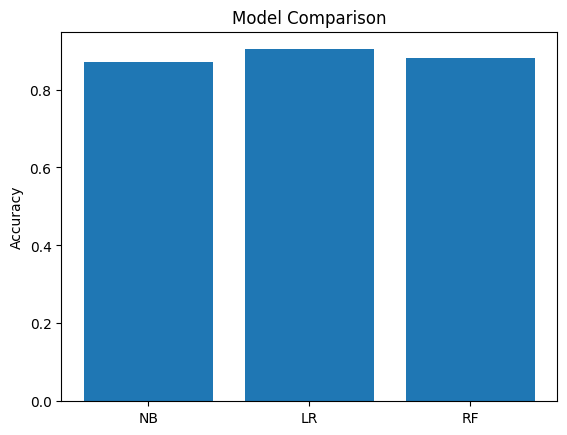

In [14]:
import matplotlib.pyplot as plt

names = []
scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    names.append(name)
    scores.append(score)

plt.bar(names, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [15]:
from sklearn.metrics import roc_curve, auc

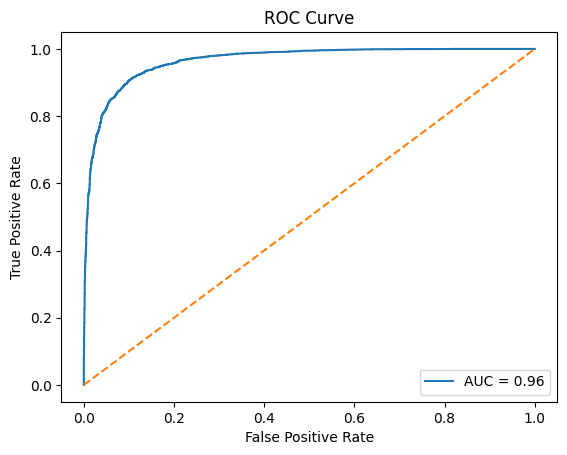

In [17]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

# Convert 'CG' and 'OR' labels to numerical (0 and 1)
# Assuming 'OR' is the positive class (1) and 'CG' is the negative class (0)
y_test_numeric = y_test.map({'CG': 0, 'OR': 1})

fpr, tpr, _ = roc_curve(y_test_numeric, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()